# Laden des Datensatzes
In der folgenden Minichallenge will ich mit dem Datensatz `SVHN` arbeiten, der eine Sammlung von Bildern von Hausnummern von Google Street View enthält. Ziel ist es die Bilder zu klassifizieren und die Ziffern zu erkennen.

In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.tensorboard import SummaryWriter
import os

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold

# Transformieren der Bilder in Tensoren und Normalisieren
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

In [41]:
# Laden des SVHN-Datensatzes
train_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

Using downloaded and verified file: ./data\train_32x32.mat
Using downloaded and verified file: ./data\test_32x32.mat
73257
26032


In [42]:
# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

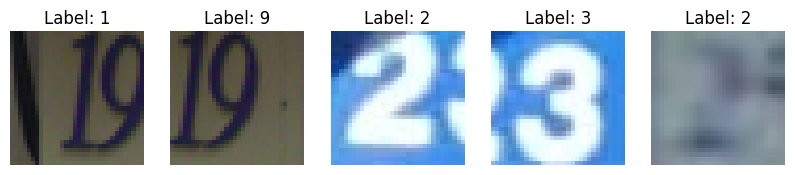

In [43]:
# Bilder anzeigen mit ihren Labels
plt.figure(figsize=(10, 2))

for i in range(5):
    image, label = train_dataset[i]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f'Label: {label}')
    plt.axis('off')

plt.show()

# Explorative Datenanalyse
Zuerst soll der Datensatz kurz analysiert werden, um ein besseres Verständnis für die Daten zu bekommen. Dazu wird die Anzahl der Bilder, die Verteilung der Klassen und details in den Bildern untersucht.

In [44]:
# Anzahl der Bilder und Bildgrösse
print("Anzahl Trainingsbilder:", len(train_dataset))

image, label = train_dataset[0]

print("Bildgrösse:", image.shape)

Anzahl Trainingsbilder: 73257
Bildgrösse: torch.Size([3, 32, 32])


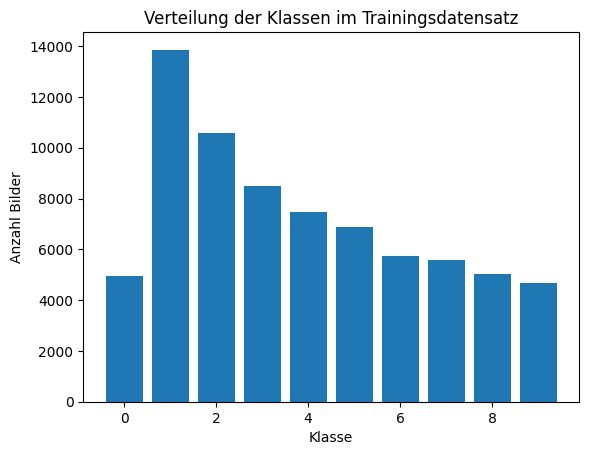

In [45]:
# Klassenverteilung
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique_labels, counts = np.unique(labels, return_counts=True)

plt.bar(unique_labels, counts)
plt.xlabel('Klasse')
plt.ylabel('Anzahl Bilder')
plt.title('Verteilung der Klassen im Trainingsdatensatz')
plt.show()

In der KLassenverteilung sieht man, dass die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. Dies ergibt durchaus Sinn, wenn man bedenkt woher die Bilder stammen. Hausnummern beginnen meistens bei 1 und bei danach werden die Zahlen immer seltener, da es zwar oft Hausnummern mit 11 oder 12 gibt aber selten eine 99 oder 100. Diese Imbalance könnte sich negativ auf die Performance des Modells auswirken.

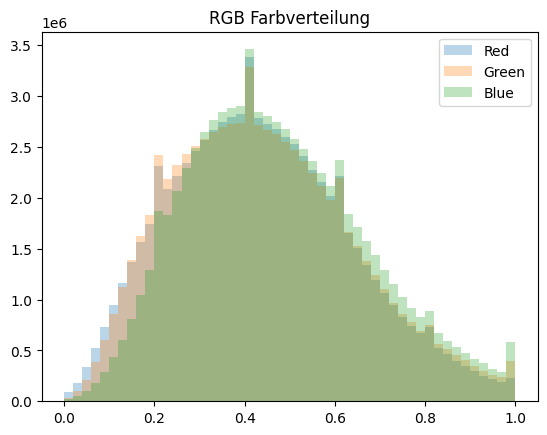

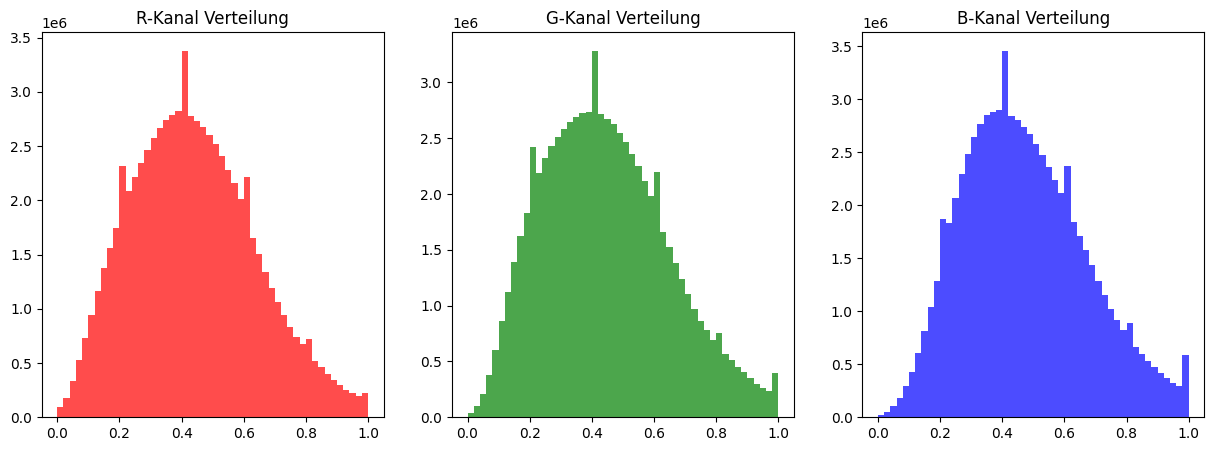

In [46]:
# Farbverteilung
all_pixels = []

for i in range(len(train_dataset)):
    img, _ = train_dataset[i]
    all_pixels.append(img.numpy())

all_pixels = np.concatenate(all_pixels, axis=1)

r = all_pixels[0].flatten()
g = all_pixels[1].flatten()
b = all_pixels[2].flatten()

plt.hist(r, bins=50, alpha=0.3, label="Red")
plt.hist(g, bins=50, alpha=0.3, label="Green")
plt.hist(b, bins=50, alpha=0.3, label="Blue")

plt.legend()
plt.title("RGB Farbverteilung")
plt.show()

# Detailplots für jede Farbe
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(r, bins=50, color='red', alpha=0.7)
plt.title("R-Kanal Verteilung")
plt.subplot(1, 3, 2)
plt.hist(g, bins=50, color='green', alpha=0.7)
plt.title("G-Kanal Verteilung")
plt.subplot(1, 3, 3)
plt.hist(b, bins=50, color='blue', alpha=0.7)
plt.title("B-Kanal Verteilung")
plt.show()

# Definieren der Evaluation Metriken
Um die Performance des Modells zu bewerten, werden folgende Metriken definiert:

Accuracy: Die Accuracy gibt an, wie viele der vorhergesagten Klassen korrekt sind.  
Formel: $\text{Accuracy} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Gesamtanzahl der Vorhersagen}}$

Precision: Die Precision gibt an, wie viele der vorhergesagten Klassen tatsächlich zur jeweiligen Klasse gehören.  
Formel: $\text{Precision} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der vorhergesagten Klassen}} = \frac{TP}{TP + FP}$

Recall: Der Recall gibt an, wie viele der tatsächlichen Klassen korrekt vorhergesagt wurden.  
Formel: $\text{Recall} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der tatsächlichen Klassen}} = \frac{TP}{TP + FN}$

F1-Score: Der F1-Score ist das Mittel von Precision und Recall und gibt eine ausgewogene Bewertung der Performance des Modells.  
Formel: $\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

# Deep Learning Pipeline

In [47]:
class BaselineCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [48]:
def train_epoch(model, loader, optimizer, criterion, device):

    model.train()       # Model wird in Trainingsmodus versetzt

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:       # Durchlaufen jedes Batches

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Alte Gradienten werden zurückgesetzt auf 0

        outputs = model(images)         # Forward Pass durch das Modell

        loss = criterion(outputs, labels)   # Berechnen des Loss

        loss.backward()         # Backward Pass: Berechnen der Gradienten
        optimizer.step()        # Updaten der Gewichte

        total_loss += loss.item()   # Loss zum totalen Loss hinzufügen

        preds = outputs.argmax(1)   # Vorhersagen durch Auswahl der Klasse mit höchster Wahrscheinlichkeit

        correct += (preds == labels).sum().item()   # Anzahl korrekter Vorhersagen
        total += labels.size(0)     # Gesamtanzahl der Bilder

    acc = correct / total       # Berechnen der Genauigkeit

    return total_loss/len(loader), acc

In [49]:
def evaluate(model, loader, criterion, device):

    model.eval()            # Model wird in Evaluationsmodus versetzt

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():   # Deaktivieren der Gradientenberechnung

        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)     # Forward Pass durch das Modell

            loss = criterion(outputs, labels)   # Berechnen des Loss

            total_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total

    return total_loss/len(loader), acc

## Model Setup
Nachfolgend wird das Model definiert. Zuerst wird die GPU als Device eingeführt. Das CNN wird erstellt, die Loss Funktion definiert, ein SGD-Optimizer mit bestimmter learning Rate erstellt

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

cuda


In [51]:
# TensorBoard Writer erstellen
log_dir = "./runs/svhn-baseline"
writer = SummaryWriter(log_dir=log_dir)

print(f"TensorBoard logs werden gespeichert in: {log_dir}")

TensorBoard logs werden gespeichert in: ./runs/svhn-baseline


## Overfitting
Im ersten Teil wird das Modell nur auf einem einzigen Bild trainiert, um zu sehen, ob es in der Lage ist, dieses Bild korrekt zu klassifizieren.

Im Anschluss soll das gleich noch mit einem kleinen Datensatz von einem Batch von 32 Bildern gemacht werden. Auch hier ist das Ziel, dass das Modell overfittet und die Bilder korrekt klassifiziert.

In [ ]:
# Overfit Test: Trainiere nur auf einem Sample
print("=" * 50)
print("OVERFITTING TEST: Ein Sample")
print("=" * 50)

model_test = BaselineCNN().to(device)
optimizer_test = optim.SGD(model_test.parameters(), lr=0.01)
criterion_test = nn.CrossEntropyLoss()

# Einen Sample nehmen
sample_image, sample_label = train_dataset[0]
sample_image = sample_image.unsqueeze(0).to(device)
sample_label = sample_label.unsqueeze(0).to(device)

# Mit diesem einen Sample für viele Epochen trainieren
test_epochs = 30
test_losses = []

for epoch in range(test_epochs):
    model_test.train()
    optimizer_test.zero_grad()
    
    output = model_test(sample_image)
    loss = criterion_test(output, sample_label)
    loss.backward()
    optimizer_test.step()
    
    test_losses.append(loss.item())

# Visualisieren
plt.figure(figsize=(10, 4))
plt.plot(test_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting Test: Loss mit 1 Sample")
plt.grid()
plt.show()

print(f"Finaler Loss mit 1 Sample: {test_losses[-1]:.4f}")

In [ ]:
# Overfit Test: Trainiere nur auf einem Batch von 32 Samples
print("\n" + "=" * 50)
print("OVERFITTING TEST: Ein Batch")
print("=" * 50)

model_test = BaselineCNN().to(device)
optimizer_test = optim.SGD(model_test.parameters(), lr=0.01)

# Einen Batch nehmen
batch_images, batch_labels = next(iter(DataLoader(train_dataset, batch_size=32)))
batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

test_epochs = 30
test_losses_batch = []

for epoch in range(test_epochs):
    model_test.train()
    optimizer_test.zero_grad()
    
    output = model_test(batch_images)
    loss = criterion_test(output, batch_labels)
    loss.backward()
    optimizer_test.step()
    
    test_losses_batch.append(loss.item())

plt.figure(figsize=(10, 4))
plt.plot(test_losses_batch)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting Test: Loss mit 1 Batch (32 Samples)")
plt.grid()
plt.show()

print(f"Finaler Loss mit 1 Batch: {test_losses_batch[-1]:.4f}")
print("Basisfunktionalität bestätigt: Model kann Daten überfitten")

# Hyperparameter Tuning

Systematische Evaluation von Learning Rates und Batch Sizes ohne automatische Hyperparameter-Suche.

## Vorgehen:
- Learning Rates: [0.1, 0.01, 0.001]
- Batch Sizes: [32, 64, 128]
- Training: 30 Epochen pro Kombination
- Evaluation auf Testdatensatz

In [ ]:
# Hyperparameter Tuning

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 64, 128]

# Dictionary für Ergebnisse speichern
results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nTraining mit LR={lr}, Batch Size={bs}")
        print("-" * 40)
        
        # DataLoader mit aktueller Batch Size
        train_loader_tuning = DataLoader(
            train_dataset, 
            batch_size=bs, 
            shuffle=True
        )
        test_loader_tuning = DataLoader(
            test_dataset, 
            batch_size=bs, 
            shuffle=False
        )
        
        # Neues Modell
        model = BaselineCNN().to(device)
        optimizer = optim.SGD(model.parameters(), lr=lr)
        
        # Training
        train_losses = []
        train_accs = []
        test_losses = []
        test_accs = []
        
        epochs = 30
        
        for epoch in range(epochs):
            train_loss, train_acc = train_epoch(
                model, train_loader_tuning, optimizer, criterion, device
            )
            test_loss, test_acc = evaluate(
                model, test_loader_tuning, criterion, device
            )
            
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            test_losses.append(test_loss)
            test_accs.append(test_acc)
            
            if epoch % 2 == 0:
                print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}")
        
        # Speichern
        results[(lr, bs)] = {
            'train_loss': train_losses,
            'train_acc': train_accs,
            'test_loss': test_losses,
            'test_acc': test_accs,
            'final_test_acc': test_accs[-1]
        }

print("\n" + "=" * 50)
print("TUNING ABGESCHLOSSEN")
print("=" * 50)

In [ ]:
# Ergebnisse als Tabelle anzeigen
print("\nErgebnisse Zusammenfassung:")
print("-" * 70)
print(f"{'LR':<10} {'BS':<10} {'Final Test Acc':<20} {'Beste Epoch Acc':<20}")
print("-" * 70)

for (lr, bs), res in sorted(results.items()):
    final_acc = res['final_test_acc']
    best_acc = max(res['test_acc'])
    print(f"{lr:<10} {bs:<10} {final_acc:<20.4f} {best_acc:<20.4f}")

In [ ]:
# Lernkurven für alle Kombinationen plotten
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (lr, bs) in enumerate(sorted(results.keys())):
    res = results[(lr, bs)]
    
    ax = axes[idx]
    epochs_range = range(len(res['train_loss']))
    
    ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(epochs_range, res['test_loss'], label='Test Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'LR={lr}, BS={bs}')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('learning_curves_loss.png', dpi=150)
plt.show()

# Genauigkeitskurven
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (lr, bs) in enumerate(sorted(results.keys())):
    res = results[(lr, bs)]
    
    ax = axes[idx]
    epochs_range = range(len(res['train_acc']))
    
    ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2, marker='o')
    ax.plot(epochs_range, res['test_acc'], label='Test Acc', linewidth=2, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'LR={lr}, BS={bs}')
    ax.legend()
    ax.grid()
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('learning_curves_accuracy.png', dpi=150)
plt.show()

In [ ]:
# Beste Parameter finden
best_params = max(results.items(), key=lambda x: x[1]['final_test_acc'])
best_lr, best_bs = best_params[0]
best_result = best_params[1]

print("\n" + "=" * 50)
print("BESTE HYPERPARAMETER")
print("=" * 50)
print(f"Learning Rate: {best_lr}")
print(f"Batch Size: {best_bs}")
print(f"Finale Test Accuracy: {best_result['final_test_acc']:.4f}")
print(f"Beste Accuracy (Pro Epoch): {max(best_result['test_acc']):.4f}")

# Statistische Fehleranalyse mit K-Fold Cross-Validation
Hier soll geprüft werden, ob die Ergebnisse des Modells stabil sind oder ob sie stark von der Aufteilung der Daten abhängen. Dazu wird K-Fold Cross-Validation verwendet, um das Modell auf verschiedenen Datenaufteilungen zu trainieren und zu evaluieren. Ich arbeite dabei mit 5 Folds.

In [ ]:
print("\n" + "=" * 50)
print("K-Fold Cross-Validation (mit besten Parametern)")
print("=" * 50)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []
cv_results = []

fold = 0
for train_idx, val_idx in kf.split(train_dataset):
    fold += 1
    print(f"\nFold {fold}/5")
    print("-" * 40)
    
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)
    
    train_loader_cv = DataLoader(train_subset, batch_size=best_bs, shuffle=True)
    val_loader_cv = DataLoader(val_subset, batch_size=best_bs, shuffle=False)
    
    model = BaselineCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=best_lr)
    
    fold_train_accs = []
    fold_val_accs = []
    
    for epoch in range(30):
        train_loss, train_acc = train_epoch(
            model, train_loader_cv, optimizer, criterion, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader_cv, criterion, device
        )
        
        fold_train_accs.append(train_acc)
        fold_val_accs.append(val_acc)
    
    final_val_acc = fold_val_accs[-1]
    cv_accuracies.append(final_val_acc)
    
    cv_results.append({
        'fold': fold,
        'train_accs': fold_train_accs,
        'val_accs': fold_val_accs,
        'final_acc': final_val_acc
    })
    
    print(f"Finale Val Accuracy: {final_val_acc:.4f}")

# Statistisch Fehler berechnen
mean_acc = np.mean(cv_accuracies)
std_acc = np.std(cv_accuracies)
ci_95 = 1.96 * std_acc / np.sqrt(len(cv_accuracies))

print("\n" + "=" * 50)
print("CROSS-VALIDATION ERGEBNISSE")
print("=" * 50)
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Std Abweichung: {std_acc:.4f}")
print(f"95% Konfidenzintervall: [{mean_acc - ci_95:.4f}, {mean_acc + ci_95:.4f}]")
print(f"\nAkkuracies pro Fold: {[f'{acc:.4f}' for acc in cv_accuracies]}")

In [ ]:
# K-Fold Ergebnisse visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
ax1 = axes[0]
ax1.boxplot(cv_accuracies, labels=['K-Fold CV'])
ax1.scatter([1]*len(cv_accuracies), cv_accuracies, alpha=0.5, s=100)
ax1.axhline(y=mean_acc, color='r', linestyle='--', label=f'Mean: {mean_acc:.4f}')
ax1.set_ylabel('Accuracy')
ax1.set_title('K-Fold Cross-Validation Ergebnisse')
ax1.legend()
ax1.grid()

# Lernkurven pro Fold
ax2 = axes[1]
for result in cv_results:
    epochs_range = range(len(result['val_accs']))
    ax2.plot(epochs_range, result['val_accs'], marker='o', label=f"Fold {result['fold']}")

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validierungsgenauigkeit pro K-Fold')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150)
plt.show()

writer.close()
print("Alle Tensorboard Logs abgeschlossen!")